# Ejemplo Regresion Polinomica

## 1. Importar librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

## 2. Crear datos simulados no lineales

In [9]:
np.random.seed(42)
X = np.linspace(0, 10, 50).reshape(-1, 1)
y = (0.5 * (X**2)) - (2 * X )+ 3 + np.random.randn(50, 1) * 3  # relación no lineal

## 3. Ajustar modelo de regresión lineal (para comparar)

In [10]:
lin_model = LinearRegression()
lin_model.fit(X, y)
y_lin_pred = lin_model.predict(X)

## 4. Crear características polinómicas (grado 2)
**poly = PolynomialFeatures(degree=2, include_bias=False)** crea un transformador que genera nuevas características polinómicas a partir de las variables originales.\
**degree=2** Establece el grado del polinomio en segundo grado\
**include_bias=False** Si lo pones en True, agrega una columna llena de 1s (un término constante).Como el modelo de regresión ya incorpora una intersección automáticamente, no se necesita esa columna extra, por eso se deja en False.\
**X_poly = poly.fit_transform(X)** Esta línea hace dos cosas a la vez:\
**(1) Aprende** cómo transformar los datos (fit), analiza la forma de X para saber cuántos términos polinómicos generar.\
**(2) Transforma** los datos (transform), aplica la expansión polinómica a X.

In [32]:
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly2 = poly2.fit_transform(X)

poly6 = PolynomialFeatures(degree=6, include_bias=False)
X_poly6 = poly6.fit_transform(X)

## 5. Entrenar regresión polinómica
Se crea y entrena el modelo de regresión polinómica.\
Primero se usa **LinearRegression()** porque, aunque el modelo es polinómico, al transformar las variables con **PolynomialFeatures**, el problema se convierte en una regresión lineal sobre nuevas características.\
**fit()** ajusta el modelo encontrando los coeficientes del polinomio\
**predict()** calcula los valores estimados usando ese modelo ya entrenado.

In [33]:
poly2_model = LinearRegression()
poly2_model.fit(X_poly2, y)
y_poly2_pred = poly2_model.predict(X_poly2)

poly6_model = LinearRegression()
poly6_model.fit(X_poly6, y)
y_poly6_pred = poly6_model.predict(X_poly6)

## 6. Métricas de evaluación

In [34]:
print("---- Regresión Lineal ----")
print("MSE:", mean_squared_error(y, y_lin_pred))
print("R²:", r2_score(y, y_lin_pred))

print("\n---- Regresión Polinómica (grado 2) ----")
print("MSE:", mean_squared_error(y, y_poly2_pred))
print("R²:", r2_score(y, y_poly2_pred))

print("\n---- Regresión Polinómica (grado 6) ----")
print("MSE:", mean_squared_error(y, y_poly6_pred))
print("R²:", r2_score(y, y_poly6_pred))

---- Regresión Lineal ----
MSE: 26.31598215487007
R²: 0.7246911973734051

---- Regresión Polinómica (grado 2) ----
MSE: 7.178157070682444
R²: 0.9249045763686427

---- Regresión Polinómica (grado 6) ----
MSE: 6.3729648520536
R²: 0.9333282219042867


## 7. Gráfica comparativa

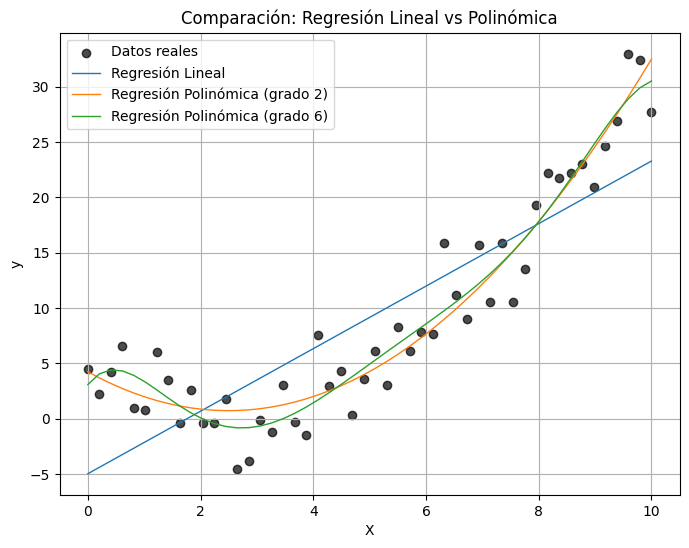

In [35]:
plt.figure(figsize=(8,6))
plt.scatter(X, y, color="black", label="Datos reales", alpha=0.7)
plt.plot(X, y_lin_pred, label="Regresión Lineal", linewidth=1)
plt.plot(X, y_poly2_pred, label="Regresión Polinómica (grado 2)", linewidth=1)
plt.plot(X, y_poly6_pred, label="Regresión Polinómica (grado 6)", linewidth=1)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Comparación: Regresión Lineal vs Polinómica")
plt.legend()
plt.grid(True)
plt.show()